In [11]:
def izhikevich_model(v, u, I, a, b):
    dv = 0.04*v**2 + 5*v + 140 - u + I
    du = a*(b*v - u)

    return dv, du

In [12]:
def I_input(t):
    if 10 < t < 90:
        return 15
    return 0

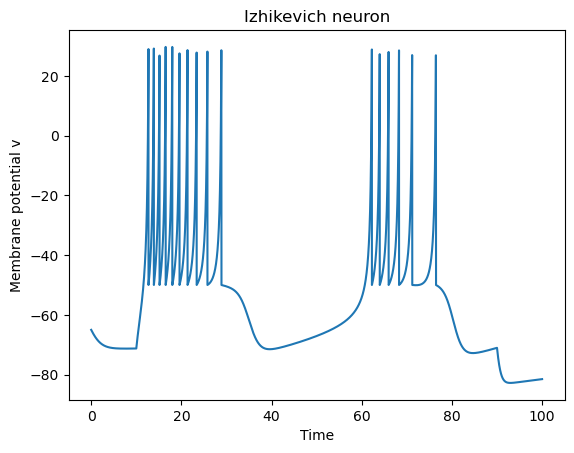

In [13]:
import numpy as np
import matplotlib.pyplot as plt

a = 0.02
b = 0.2
c = -50
d = 2

#spike condition
spike_condition = 30 

#time step size
dt = 0.01
#total simulation time - from 1 to 100
T = 100
# array of points - start: 0, end: T, step: dt 
time = np.arange(0, T, dt)
# we do it to simulate time

# initial values
v = -65
u=b*v

# store how v and u change over time
v_trace = []
u_trace = []


for t in time: # we go through every time step 0 - 0.25, 0.5, 0.75 and so on
    I = I_input(t) # we compute the external current injected into the neuron at time t - from 0 to 10 it is 0 and from 10 to 40 ms the current is 10 

    # we compute the model variables - how fast u (recovery variable) and v (voltage) are changing
    dv, du = izhikevich_model(v, u, I, a, b)

    # Euler update - new value = old value + (rate of change × time step)
    v += dt * dv
    u += dt * du

    # spike condition - if voltage over 30 a spike happens => then voltage is reset to baseline value => recovery variable increases and the neuron becomes inactive
    if v >= spike_condition:
        v = c
        u += d

    # we save the new values of v and u
    v_trace.append(v)
    u_trace.append(u)

# draw graphics
plt.plot(time, v_trace)
plt.title("Izhikevich neuron")
plt.xlabel("Time")
plt.ylabel("Membrane potential v")
plt.show()